In [101]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de reproducibilidad
np.random.seed(42)

# ==============================================================================
# 1. PARÁMETROS DE LA MALLA Y SIMULACIÓN
# ==============================================================================
Nx, Ny = 20, 20              # Tamaño de la grilla (20x20 nodos)
dx, dy = 0.5, 0.5            # Resolución espacial (km)
dt = 0.1                     # Paso de tiempo
T_steps = 60                 # Duración total (60 pasos de tiempo)

u_wind, v_wind = 0.6, 0.3    # Velocidad del viento (Advección)
K_diff = 0.10                # Coeficiente de Difusión
state_dim = Nx * Ny

x = np.linspace(0, (Nx - 1) * dx, Nx)
y = np.linspace(0, (Ny - 1) * dy, Ny)
X, Y = np.meshgrid(x, y)

In [102]:
# ==============================================================================
# 2. MODELO FÍSICO (PDE ADVECCIÓN-DIFUSIÓN 2D)
# ==============================================================================
def step_physics(C, u, v, K, dx, dy, dt, source=None):
    """Avanza 1 paso de tiempo la EDP con condiciones de frontera abiertas."""
    C_pad = np.pad(C, ((1, 1), (1, 1)), mode='edge')
    
    # Advección Upwind
    dC_dx = (C - C_pad[1:-1, :-2]) / dx if u > 0 else (C_pad[1:-1, 2:] - C) / dx
    dC_dy = (C - C_pad[:-2, 1:-1]) / dy if v > 0 else (C_pad[2:, 1:-1] - C) / dy
    
    # Difusión (Laplaciano)
    d2C_dx2 = (C_pad[1:-1, 2:] - 2.0 * C + C_pad[1:-1, :-2]) / (dx**2)
    d2C_dy2 = (C_pad[2:, 1:-1] - 2.0 * C + C_pad[:-2, 1:-1]) / (dy**2)
    
    dC_dt = -u * dC_dx - v * dC_dy + K * (d2C_dx2 + d2C_dy2)
    if source is not None:
        dC_dt += source
        
    C_next = C + dt * dC_dt
    return np.clip(C_next, 0.0, None)

def get_source(t):
    """Fuente de emisión variable (ciclo diario/diurno) cerca del centro."""
    pulse = np.sin(2 * np.pi * t / 24.0)**2
    return 4.0 * pulse * np.exp(-(((X - 4.5)**2 + (Y - 4.5)**2) / 1.5))


In [103]:
# ==============================================================================
# 3. GENERAR LA VERDAD SINTÉTICA Y MEDICIONES
# ==============================================================================
print("Generando Verdad Sintética...")
C_init = 5.0 + 8.0 * np.exp(-(((X - 2.0)**2 + (Y - 2.0)**2) / 3.0))
truth = [C_init.copy()]

C_curr = C_init.copy()
for t in range(1, T_steps):
    src = get_source(t)
    C_curr = step_physics(C_curr, u_wind, v_wind, K_diff, dx, dy, dt, source=src)
    truth.append(C_curr.copy())

truth = np.array(truth) # Forma: (T_steps, Ny, Nx)

# Ubicación de Estaciones (Coordenadas X, Y)
stations = {
    'S_Norte': (5.0, 8.0),
    'S_Sur': (5.0, 2.0),
    'S_Este': (8.0, 5.0),
    'S_Oeste': (2.0, 5.0),
    'S_Ciega (Holdout)': (4.5, 4.5)  # Estación oculta para validación
}

def coord_to_index(x_val, y_val):
    ix = int(np.clip(np.round(x_val / dx), 0, Nx - 1))
    iy = int(np.clip(np.round(y_val / dy), 0, Ny - 1))
    return iy, ix

# Muestreo con ruido Gaussiano N(0, R_std^2)
R_std = 0.000005
obs_data = {}
for code, (sx, sy) in stations.items():
    iy, ix = coord_to_index(sx, sy)
    signal = truth[:, iy, ix]
    noise = np.random.normal(0, R_std, size=T_steps)
    obs_data[code] = signal + noise

# Separar sensores de entrenamiento y la estación ciega
train_stations = {k: v for k, v in stations.items() if k != 'S_Ciega (Holdout)'}
p_train = len(train_stations)

# Matriz de Observación H (p_train x state_dim)
H_train = np.zeros((p_train, state_dim))
for i, (code, (sx, sy)) in enumerate(train_stations.items()):
    iy, ix = coord_to_index(sx, sy)
    flat_idx = iy * Nx + ix
    H_train[i, flat_idx] = 1.0

Generando Verdad Sintética...


In [116]:

# ==============================================================================
# 4. ALGORITMO ENKF (ENSEMBLE KALMAN FILTER)
# ==============================================================================
X_flat, Y_flat = X.ravel(), Y.ravel()
train_coords = np.array(list(train_stations.values()))
dx_mat = X_flat[:, None] - train_coords[:, 0][None, :]
dy_mat = Y_flat[:, None] - train_coords[:, 1][None, :]
dist_mat = np.sqrt(dx_mat**2 + dy_mat**2)

# Atenuación gaussiana con radio de corte (r_cut = 3.0 km)
r_cut = 3.0
C_mat = np.exp(-(dist_mat**2) / (2 * (r_cut / 2)**2))

N_ens = 30           # Número de miembros del ensamble
Q_std = 1.0          # Ruido de modelo
inflation = 1.03     # Factor de inflación de covarianza

# Inicializar ensamble alrededor del valor inicial promedio
ensemble = np.random.normal(np.mean(C_init), 3.0, size=(state_dim, N_ens))
ensemble = np.clip(ensemble, 0.0, None)

enkf_reconstruction = []
enkf_std_history = []

def enkf_analysis(ensemble, y_obs, H, R_std, infl, C_mat):
    x_mean = np.mean(ensemble, axis=1, keepdims=True)
    A = (ensemble - x_mean) * np.sqrt(infl)
    HA = H @ A
    
    Py = (HA @ HA.T) / (N_ens - 1) + (R_std**2) * np.eye(p_train)
    Pxy = (A @ HA.T) / (N_ens - 1)
    
    # Producto de Schur para localizar la covarianza
    Pxy_loc = C_mat * Pxy  
    
    K = Pxy_loc @ np.linalg.inv(Py)
    y_perturbed = y_obs[:, None] + np.random.normal(0, R_std, size=(p_train, N_ens))
    ensemble_updated = ensemble + K @ (y_perturbed - H @ ensemble)
    return np.clip(ensemble_updated, 0.0, None)

print("Ejecutando Asimilación de Datos EnKF...")
for t in range(T_steps):
    src = get_source(t)
    src_flat = src.ravel()
    
    # Paso 1: PRONÓSTICO (Forecast)
    for i in range(N_ens):
        c_member = ensemble[:, i].reshape((Ny, Nx))
        c_next = step_physics(c_member, u_wind, v_wind, K_diff, dx, dy, dt, source=src)
        # Inyección de ruido de modelo
        noise = np.random.normal(0, Q_std, size=(Ny, Nx))
        ensemble[:, i] = np.clip(c_next + noise, 0.0, None).ravel()
        
    # Paso 2: ANÁLISIS (Update con observaciones)
    y_t = np.array([obs_data[code][t] for code in train_stations.keys()])
    ensemble = enkf_analysis(ensemble, y_t, H_train, R_std, inflation, C_mat)
    
    # Guardar media del ensamble
    mean_state = np.mean(ensemble, axis=1).reshape((Ny, Nx))
    enkf_reconstruction.append(mean_state.copy())

    std_state = np.std(ensemble, axis=1).reshape((Ny, Nx))
    enkf_std_history.append(std_state)

enkf_reconstruction = np.array(enkf_reconstruction)
enkf_std_history = np.array(enkf_std_history)

Ejecutando Asimilación de Datos EnKF...



 RESULTADOS EN LA ESTACIÓN CIEGA (S_Ciega (Holdout))
 • KGE:  0.524  (r=0.92, α=0.54, β=0.90)
 • R²:   0.852
 • RMSE: 1.419 µg/m³



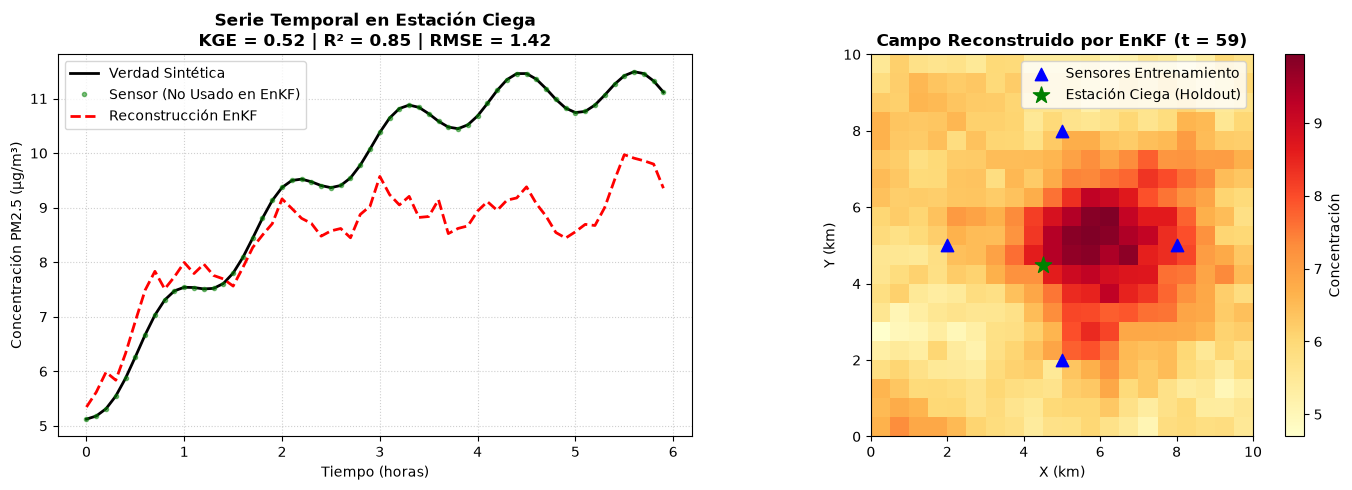

In [117]:
# ==============================================================================
# 5. EVALUACIÓN Y MÉTRICAS EN LA ESTACIÓN CIEGA
# ==============================================================================
holdout_code = 'S_Ciega (Holdout)'
iy_h, ix_h = coord_to_index(*stations[holdout_code])

y_true_h = truth[:, iy_h, ix_h]
y_pred_h = enkf_reconstruction[:, iy_h, ix_h]

# Cálculo de métricas (RMSE, R2, KGE)
rmse = np.sqrt(np.mean((y_true_h - y_pred_h)**2))
r_corr = np.corrcoef(y_true_h, y_pred_h)[0, 1]
r2 = r_corr**2
alpha = np.std(y_pred_h) / np.std(y_true_h)
beta = np.mean(y_pred_h) / np.mean(y_true_h)
kge = 1.0 - np.sqrt((r_corr - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)

print("\n" + "="*50)
print(f" RESULTADOS EN LA ESTACIÓN CIEGA ({holdout_code})")
print("="*50)
print(f" • KGE:  {kge:.3f}  (r={r_corr:.2f}, α={alpha:.2f}, β={beta:.2f})")
print(f" • R²:   {r2:.3f}")
print(f" • RMSE: {rmse:.3f} µg/m³")
print("="*50 + "\n")

# ==============================================================================
# 6. VISUALIZACIÓN GRÁFICA
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Gráfica 1: Serie de Tiempo en el Punto Ciego
time_axis = np.arange(T_steps) * dt
axes[0].plot(time_axis, y_true_h, 'k-', label='Verdad Sintética', linewidth=2)
axes[0].plot(time_axis, obs_data[holdout_code], 'g.', label='Sensor (No Usado en EnKF)', alpha=0.5)
axes[0].plot(time_axis, y_pred_h, 'r--', label='Reconstrucción EnKF', linewidth=2)
axes[0].set_title(f"Serie Temporal en Estación Ciega\nKGE = {kge:.2f} | R² = {r2:.2f} | RMSE = {rmse:.2f}", fontweight='bold')
axes[0].set_xlabel('Tiempo (horas)')
axes[0].set_ylabel('Concentración PM2.5 (µg/m³)')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Gráfica 2: Campo Espacial en el último instante t
im = axes[1].imshow(enkf_reconstruction[-1], origin='lower', extent=[0, Nx*dx, 0, Ny*dy], cmap='YlOrRd')
axes[1].scatter([v[0] for k, v in train_stations.items()], [v[1] for k, v in train_stations.items()], 
               color='blue', marker='^', s=80, label='Sensores Entrenamiento')
axes[1].scatter(stations[holdout_code][0], stations[holdout_code][1], 
               color='green', marker='*', s=150, label='Estación Ciega (Holdout)')
axes[1].set_title(f"Campo Reconstruido por EnKF (t = {T_steps-1})", fontweight='bold')
axes[1].set_xlabel('X (km)')
axes[1].set_ylabel('Y (km)')
plt.colorbar(im, ax=axes[1], label='Concentración')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

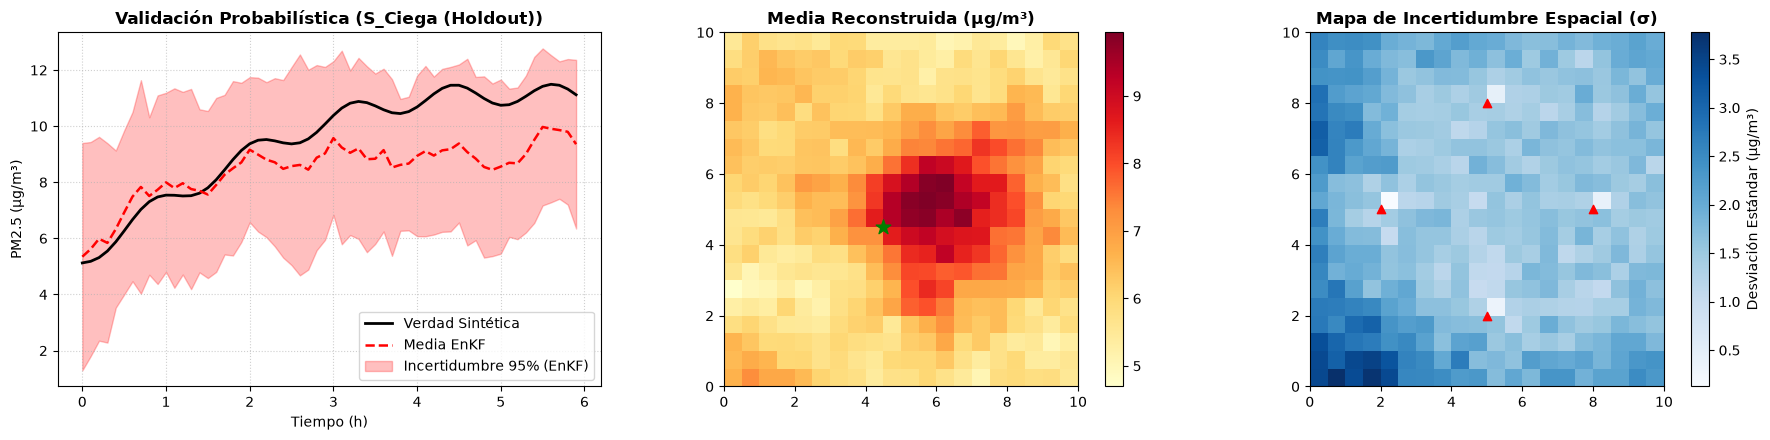

In [118]:
# --- Dentro del bucle del EnKF, guarda la std espacial ---
# std_state = np.std(ensemble, axis=1).reshape((Ny, Nx))
# enkf_std_history.append(std_state)

# --- CÓDIGO DE VISUALIZACIÓN MEJORADO ---
std_h = enkf_std_history[:, iy_h, ix_h]
ci_95 = 1.96 * std_h

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100)

# 1. Serie Temporal con Banda de Confianza (Estación Ciega)
axes[0].plot(time_axis, y_true_h, 'k-', label='Verdad Sintética', linewidth=2)
axes[0].plot(time_axis, y_pred_h, 'r--', label='Media EnKF', linewidth=1.8)
axes[0].fill_between(time_axis, y_pred_h - ci_95, y_pred_h + ci_95, color='red', alpha=0.25, label='Incertidumbre 95% (EnKF)')
axes[0].set_title(f"Validación Probabilística ({holdout_code})", fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Tiempo (h)')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 2. Campo Espacial Promedio (Reconstrucción)
im1 = axes[1].imshow(enkf_reconstruction[-1], origin='lower', extent=[0, Nx*dx, 0, Ny*dy], cmap='YlOrRd')
axes[1].scatter(stations[holdout_code][0], stations[holdout_code][1], color='green', marker='*', s=120)
axes[1].set_title("Media Reconstruida (µg/m³)", fontweight='bold')
plt.colorbar(im1, ax=axes[1])

# 3. Mapa de Incertidumbre Espacial (Desviación Estándar)
im2 = axes[2].imshow(enkf_std_history[-1], origin='lower', extent=[0, Nx*dx, 0, Ny*dy], cmap='Blues')
axes[2].scatter([v[0] for k, v in train_stations.items()], [v[1] for k, v in train_stations.items()], color='red', marker='^', label='Sensores')
axes[2].set_title("Mapa de Incertidumbre Espacial (σ)", fontweight='bold')
plt.colorbar(im2, ax=axes[2], label='Desviación Estándar (µg/m³)')

plt.tight_layout()
plt.show()

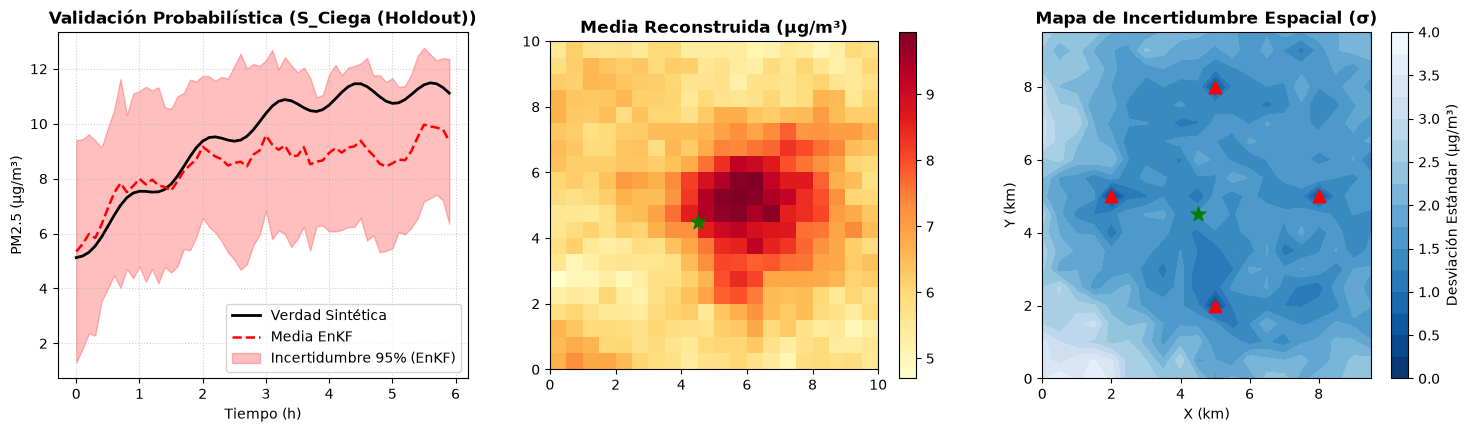

In [119]:
# 3. Mapa de Incertidumbre Espacial con Contornos Nítidos
# --- Dentro del bucle del EnKF, guarda la std espacial ---
# std_state = np.std(ensemble, axis=1).reshape((Ny, Nx))
# enkf_std_history.append(std_state)

# --- CÓDIGO DE VISUALIZACIÓN MEJORADO ---
std_h = enkf_std_history[:, iy_h, ix_h]
ci_95 = 1.96 * std_h

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100)

# 1. Serie Temporal con Banda de Confianza (Estación Ciega)
axes[0].plot(time_axis, y_true_h, 'k-', label='Verdad Sintética', linewidth=2)
axes[0].plot(time_axis, y_pred_h, 'r--', label='Media EnKF', linewidth=1.8)
axes[0].fill_between(time_axis, y_pred_h - ci_95, y_pred_h + ci_95, color='red', alpha=0.25, label='Incertidumbre 95% (EnKF)')
axes[0].set_title(f"Validación Probabilística ({holdout_code})", fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Tiempo (h)')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 2. Campo Espacial Promedio (Reconstrucción)
im1 = axes[1].imshow(enkf_reconstruction[-1], origin='lower', extent=[0, Nx*dx, 0, Ny*dy], cmap='YlOrRd')
axes[1].scatter(stations[holdout_code][0], stations[holdout_code][1], color='green', marker='*', s=120)
axes[1].set_title("Media Reconstruida (µg/m³)", fontweight='bold')
plt.colorbar(im1, ax=axes[1])

ax3 = axes[2]
cf = ax3.contourf(X, Y, enkf_std_history[-1], levels=15, cmap='Blues_r')
ax3.scatter([v[0] for k, v in train_stations.items()], 
            [v[1] for k, v in train_stations.items()], 
            color='red', marker='^', s=80, label='Sensores', zorder=5)
ax3.scatter(stations[holdout_code][0], stations[holdout_code][1], 
            color='green', marker='*', s=120, label='Holdout', zorder=5)
ax3.set_title("Mapa de Incertidumbre Espacial (σ)", fontweight='bold')
ax3.set_xlabel('X (km)')
ax3.set_ylabel('Y (km)')
plt.colorbar(cf, ax=ax3, label='Desviación Estándar (µg/m³)')